In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
import plotly.graph_objects as go
from keras.callbacks import EarlyStopping

import os
import pickle
from datetime import datetime
import tensorflow as tf
from keras.models import load_model

# Exercise 11

The goal of this exercise is to explore the phenomenology of Feed Forward Neural Networks. In the first part, I will focus on the impact of various hyperparameters on the performance of the network. In the second part, I will try to make the network learn to predict a polynomial function and explore the fundamental inadequacy of neural networks for extrapolation. The third part will focus on the prediction of a complex 2D function. 

_**Note:** Every time the saving logic is implemented, there is a `force_retrain` parameter that is set to `False` by default. If this is set to `True`, the model is retrained, but the previous files are not overwritten because a timestamp is appended to the new filename. If you want to retrain the model or change any hyperparameters, you should set `force_retrain` to `True`, otherwise the model will simply be loaded from the corresponding file in the directory. For the models that are very fast to train there is no saving logic._

## Exercise 11.1: Parameter Space Exploration
To understand the dynamics of this Neural Network, I will systematically explore the parameter space by isolating three key variables:
1. **Dataset Size ($N_{\mathrm{train}}$):** How much information the network has to learn from.
2. **Training Duration ($N_{\mathrm{epochs}}$):** How long the network is allowed to search for the optimal weights.
3. **Data Noise ($\sigma$):** The amount of random variance obscuring the underlying mathematical truth.

I will proceed through a matrix of 4 trials (combining low/high data sizes with low/high epoch counts) before intentionally pushing a complex model to overfit the noise. What happens when we reduce the noise is quite straightforward and will be shown at last.

### Set up model

In [2]:
# Target parameters
m = 2 
q = 1 
sigma = 0.2 

def run_regression_trial(n_train, n_valid, epochs, batch_size, trial_name):
    """Generates data, trains a 1-neuron model, and plots the results side-by-side."""
    
    # Generate Data
    x_train = np.random.uniform(-1, 1, n_train)
    x_valid = np.random.uniform(-1, 1, n_valid)
    x_valid.sort()

    y_train = np.random.normal(m * x_train + q, sigma)
    y_valid = np.random.normal(m * x_valid + q, sigma)

    # Build and Train Model
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(1,))),
    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer='sgd', 
        loss='mse', 
        metrics=['mse'])
    
    # verbose=0 keeps the notebook clean by hiding the progress bar
    history = model.fit(x_train, 
                        y_train, 
                        batch_size=batch_size, 
                        epochs=epochs, 
                        validation_data=(x_valid, y_valid), 
                        shuffle=True, 
                        verbose=0) 

    # Plotting (side-by-side)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{trial_name} (N={n_train}, Epochs={epochs})", fontsize=14, fontweight='bold')

    # Left Plot: Loss Curve
    ax1.plot(history.history['loss'], label='Training MSE')
    ax1.plot(history.history['val_loss'], label='Validation MSE')
    ax1.set_title('Model Loss over Time')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    # Right Plot: Predictions vs Target
    ax2.scatter(x_train, y_train, marker='.', c='b', alpha=0.3, label='Training data')
    ax2.scatter(x_valid, y_valid, marker='x', c='g', label='Validation data')
    
    x_plot = np.linspace(-1, 1, 100)
    ax2.plot(x_plot, m*x_plot + q, c='r', linewidth=2, label='Target function')
    ax2.plot(x_plot, model.predict(x_plot, verbose=0), c='orange', linewidth=2, label='Predicted function')
    
    ax2.set_title("Function Prediction")
    ax2.set_xlabel("x [a.u.]")
    ax2.set_ylabel("y [a.u.]")
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Running the Parameter Matrix
We now execute the 4 configurations to observe how the network behaves under varying constraints.

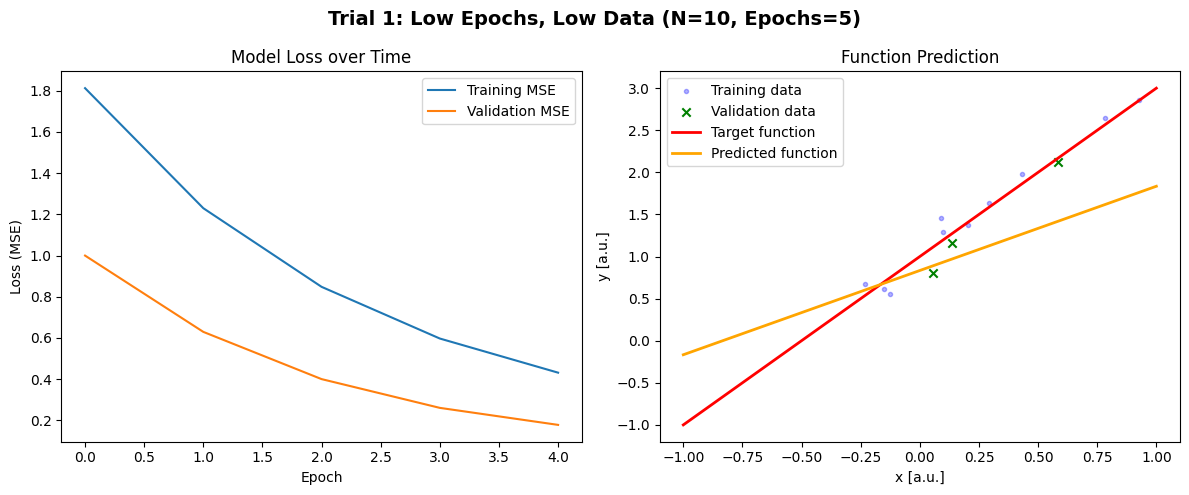

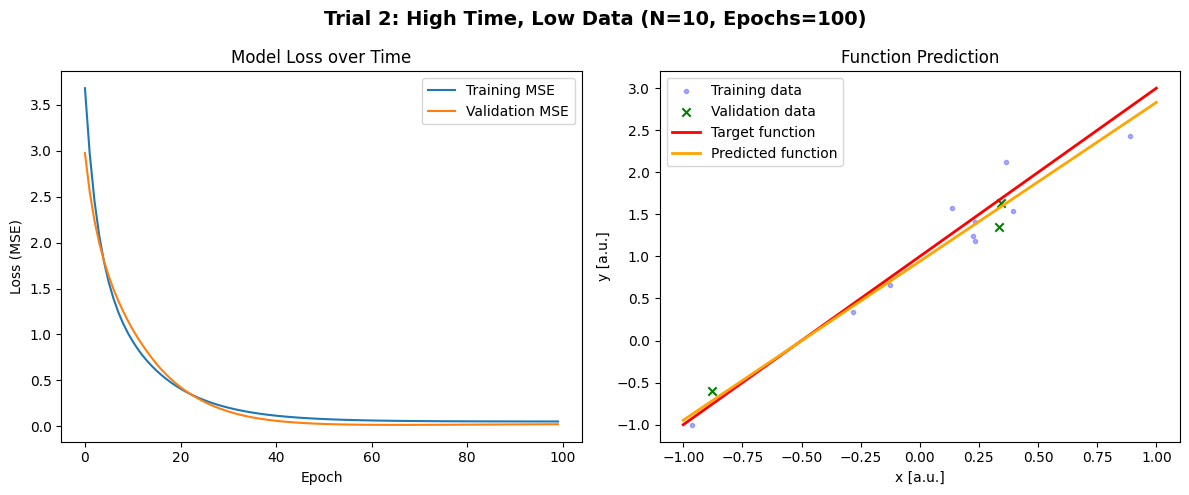

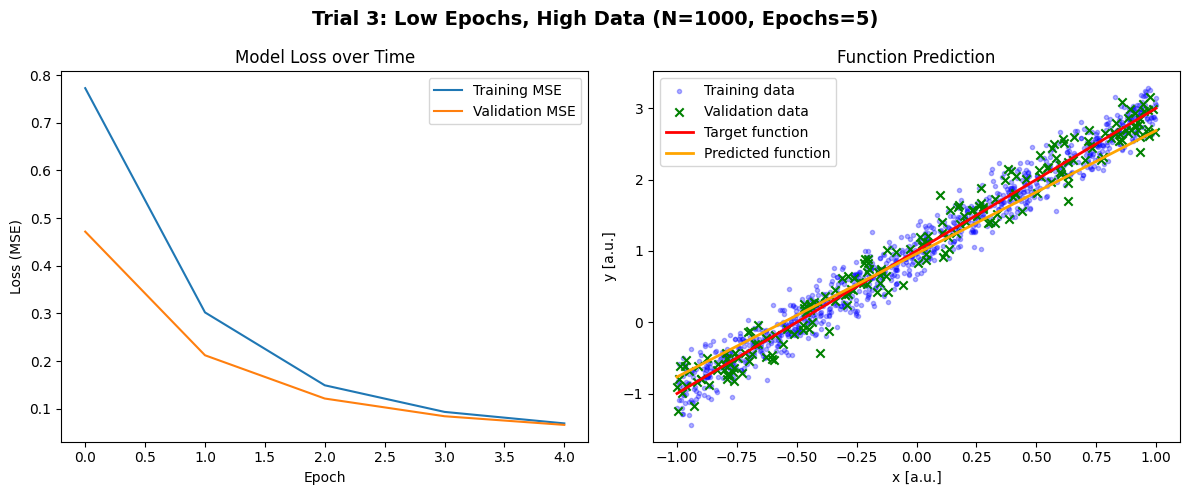

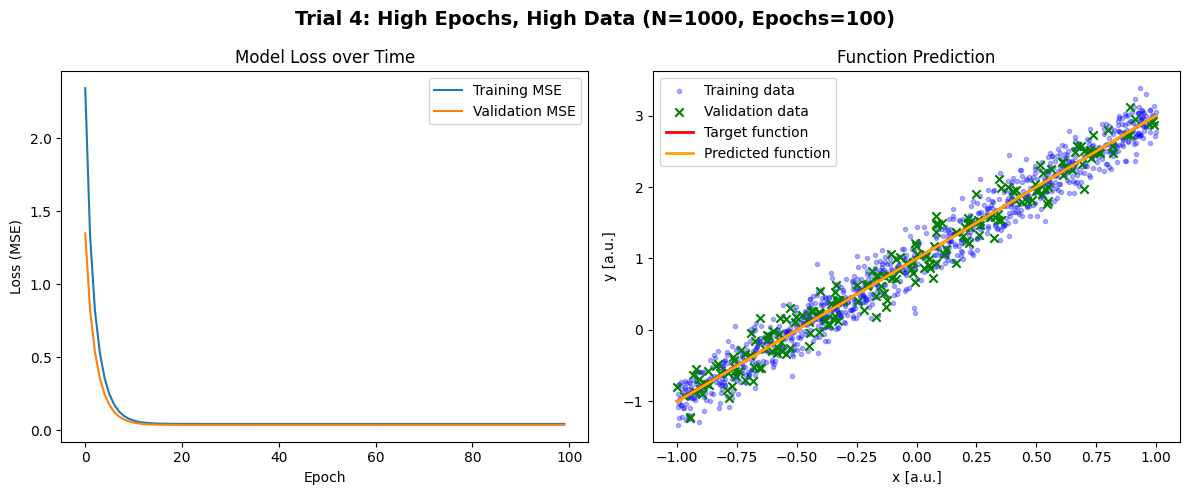

In [3]:
np.random.seed(0)
# tf.random.set_seed(0)

# Trial 1: Small dataset, small number of epochs
run_regression_trial(n_train=10, n_valid=3, epochs=5, batch_size=1, trial_name="Trial 1: Low Epochs, Low Data")

# Trial 2: Small dataset, big number of epochs
run_regression_trial(n_train=10, n_valid=3, epochs=100, batch_size=1, trial_name="Trial 2: High Time, Low Data")

# Trial 3: Big dataset, small number of epochs
run_regression_trial(n_train=1000, n_valid=200, epochs=5, batch_size=32, trial_name="Trial 3: Low Epochs, High Data")

# Trial 4: Big dataset, big number of epochs
run_regression_trial(n_train=1000, n_valid=200, epochs=100, batch_size=32, trial_name="Trial 4: High Epochs, High Data")

By systematically isolating dataset size ($N_{\mathrm{train}}$) and training duration ($N_{\mathrm{epochs}}$), we can observe how the network navigates its parameter space across four distinct scenarios:

* **Trial 1 (Low Data, Low Epochs):** The model fails to approximate the target function entirely. With only 10 noisy data points, the network lacks a clear mathematical representation of the underlying trend. Furthermore, stopping after just 5 epochs means the optimizer has barely begun its descent down the loss gradient; the final weights essentially remain in their randomized initial state. Running the code multiple times without the `tf.random.set_seed()` produces very variable results.
* **Trial 2 (Low Data, High Epochs):** The model successfully minimizes its loss, but the resulting prediction is poor. Because the dataset is so small, the optimizer converges on a "false" minimum dictated by the specific random placement of those few noisy points. The network has over-optimized for an unrepresentative sample, proving that ample training time cannot fix a fundamentally impoverished dataset.
* **Trial 3 (High Data, Low Epochs):** The prediction is highly unstable. While the dense dataset of 1000 points provides a smooth, accurate loss landscape pointing directly toward the true target function, the optimizer is prematurely halted. Gradient descent is an iterative process; giving the network a perfect map is useless if we do not give it enough time to walk to the destination.
* **Trial 4 (High Data, High Epochs):** The model achieves a near-perfect fit. The massive volume of data effectively "cancels out" the random noise ($\sigma$), providing a true gradient. Given an adequate number of epochs, the optimizer reliably traces this gradient down to the absolute global minimum, perfectly recovering the original parameters ($m=2$, $q=1$).

**Conclusion:** Data quantity and training duration are strictly complementary in deep learning. An abundance of high-quality data defines the correct path to the solution, but the network still requires sufficient epochs to travel that path.

### Noise reduction

Let's consider a situation with a very small but very clean dataset. The variance (noise) is very low, the model has adequate complexity, and it is trained for a sufficiently long time. Having this extremely clean data allows the model to make a highly accurate prediction. 

This experiment perfectly illustrates the positive side of the "garbage in, garbage out" principle: data quality dictates model quality. In particular, if the dataset we feed the network is pristine, the network can provide an excellent prediction even if the dataset is incredibly small. Therefore, when designing an experiment, one must recognize the trade-off between quantity and quality: a lack of vast amounts of data can often be compensated for by ensuring the data you do have is extremely clean.

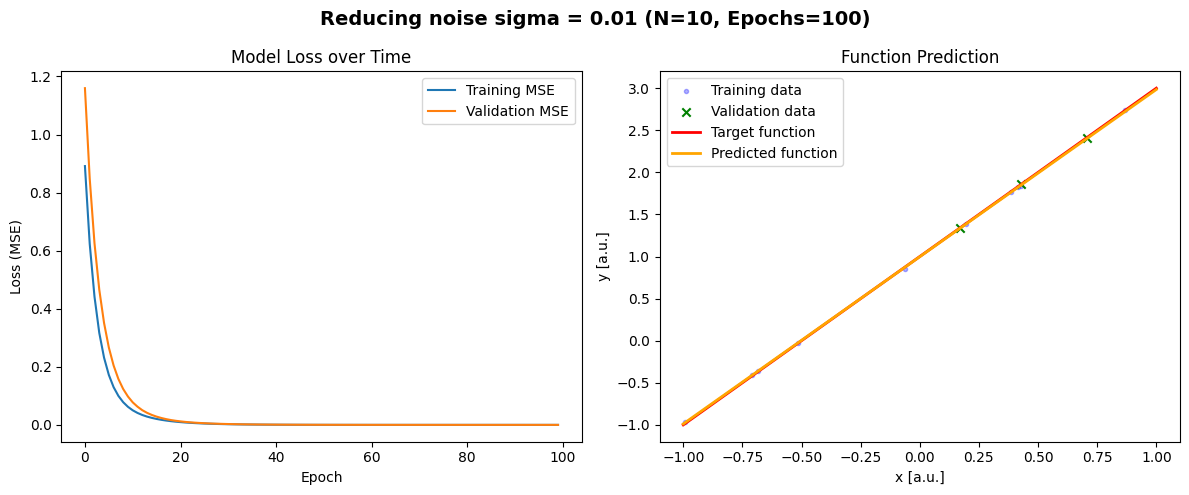

In [4]:
sigma = 0.01
run_regression_trial(n_train=10, n_valid=3, epochs=100, batch_size=1, trial_name=f"Reducing noise sigma = {sigma}")

### Overfitting
A single-neuron linear model cannot overfit data because its mathematical capacity is restricted to drawing a straight line. To observe overfitting, we must introduce **non-linearity** and **excess capacity**.

In this test, I will define a highly complex, multi-layer network with `relu` activations. We will train this same architecture on two different datasets (sparse vs. dense) to observe how data quantity interacts with model complexity.

In [5]:
# Hyperparameter Configuration
n_layers = 4
n_neurons = 64
activation_func = 'relu'
n_epochs = 2000
batch_sz = 32

sigma = 0.4 # Higher noise to encourage overfitting

# Creates a name like: "model_4x64_swish_1500ep.keras"
signature = f"{n_layers}x{n_neurons}_{activation_func}_{n_epochs}ep"
base_model_name = f"overfit_model_{signature}"
base_history_name = f"overfit_history_{signature}"

def run_complex_model_trial(n_train, n_valid, batch_size, title, force_retrain=False):
    """Trains a highly over-parameterized model and plots the results."""

    # Generate Data
    np.random.seed(0)
    tf.random.set_seed(0)
    
    x_train = np.random.uniform(-1, 1, n_train)
    x_valid = np.random.uniform(-1, 1, n_valid)
    x_valid.sort()

    y_train = np.random.normal(m * x_train + q, sigma)
    y_valid = np.random.normal(m * x_valid + q, sigma)


    # Load or Train
    if os.path.exists(base_model_name+f'_{n_train}tr.keras') and not force_retrain:
        print(f"Loading existing model from '{base_model_name}.keras'...")
    
        model = load_model(base_model_name+f'_{n_train}tr.keras')
    
        with open(base_history_name+f'_{n_train}tr.pkl', "rb") as file_pi:
            loaded_history_dict = pickle.load(file_pi)
            class MockHistory: pass
            history = MockHistory()
            history.history = loaded_history_dict

    else:
        print(f"Building and training new model ({signature})...")
    
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.Input(shape=(1,)))
    
        # Dynamically build the hidden layers based on the config above
        for _ in range(n_layers):
            model.add(tf.keras.layers.Dense(n_neurons, activation=activation_func))
        
        model.add(tf.keras.layers.Dense(1))

        model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

        history = model.fit(
            x = x_train, y = y_train,
            batch_size = batch_size, epochs = n_epochs,
            shuffle=True, validation_data=(x_valid, y_valid),
            verbose=0 
        )
    
        # Determine Filenames (Avoid overwriting an existing model)
        if os.path.exists(base_model_name+f'_{n_train}tr.keras') and force_retrain:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            save_model_name = f"overfit_model_{signature}_{timestamp}_{n_train}tr.keras"
            save_history_name = f"overfit_history_{signature}_{timestamp}_{n_train}tr.pkl"
            print("Base file exists. Saving as distinct files with timestamp.")
        else:
            save_model_name = base_model_name+f'_{n_train}tr.keras'
            save_history_name = base_history_name+f'_{n_train}tr.pkl'
        
        # Save Model and History
        model.save(save_model_name)
        with open(save_history_name, 'wb') as file_pi:
            pickle.dump(history.history, file_pi)

        print(f"Training complete. Files saved as '{save_model_name}'")

    # Plotting (side-by-side)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Loss Curve
    ax1.plot(history.history['loss'], label='Training MSE')
    ax1.plot(history.history['val_loss'], label='Validation MSE')
    ax1.set_title('Model Loss over Time')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    # Prediction Plot
    ax2.scatter(x_train, y_train, marker='.', c='b', alpha=0.3, label='Training data')
    ax2.scatter(x_valid, y_valid, marker='x', c='g', alpha=0.3, label='Validation data')

    # Use high resolution (300 points) to properly see the wiggles
    x_plot = np.linspace(-1, 1, 300) 
    ax2.plot(x_plot, m*x_plot + q, c='r', linewidth=2, linestyle='--', label='Target function')
    ax2.plot(x_plot, model.predict(x_plot, verbose=0), c='orange', linewidth=2, label='Predicted function')

    ax2.set_title("Function Prediction")
    ax2.set_xlabel("x [a.u.]")
    ax2.set_ylabel("y [a.u.]")
    ax2.legend()

    plt.tight_layout()
    plt.show()

#### Scenario A: Sparse Data ($N=15$)
By using a small dataset with high noise, I expect the network to stop generalizing the core function ($y = 2x + 1$) and instead begin weaving its predictions through the random noise fluctuations.

Loading existing model from 'overfit_model_4x64_relu_2000ep.keras'...


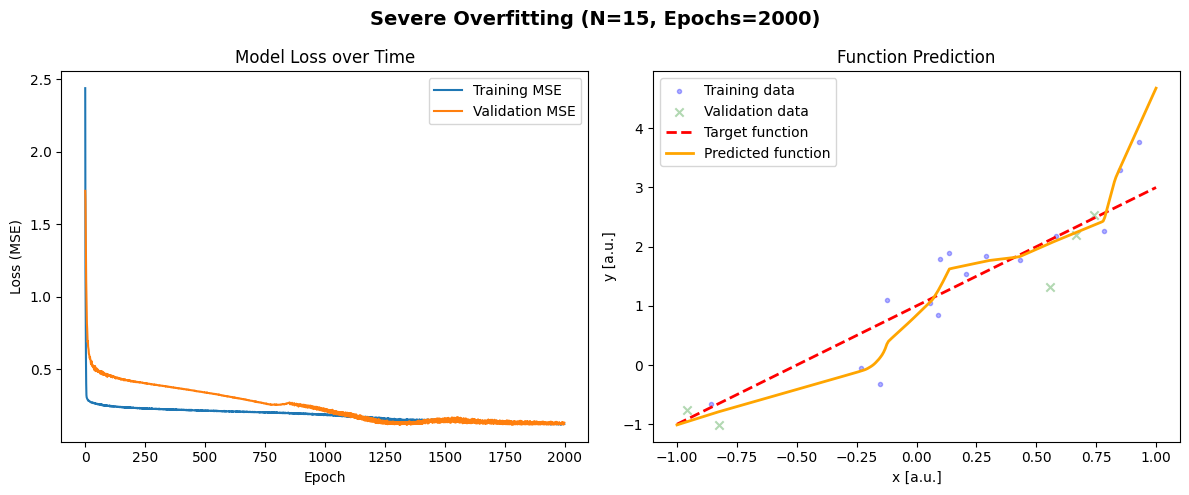

In [6]:
# Train the massive network on just 15 points
run_complex_model_trial(n_train=15, n_valid=5, batch_size=1, 
                        title="Severe Overfitting (N=15, Epochs=2000)", force_retrain=False)

#### Scenario B: The Effect of Increasing Data Density ($N=1000$)
What happens if we use the exact same over-parameterized network, but flood it with data? If noise is unavoidable, increasing the density of data should improve the quality of the prediction by providing conflicting gradients that "soften" the extreme wiggles of overfitting.

Loading existing model from 'overfit_model_4x64_relu_2000ep.keras'...


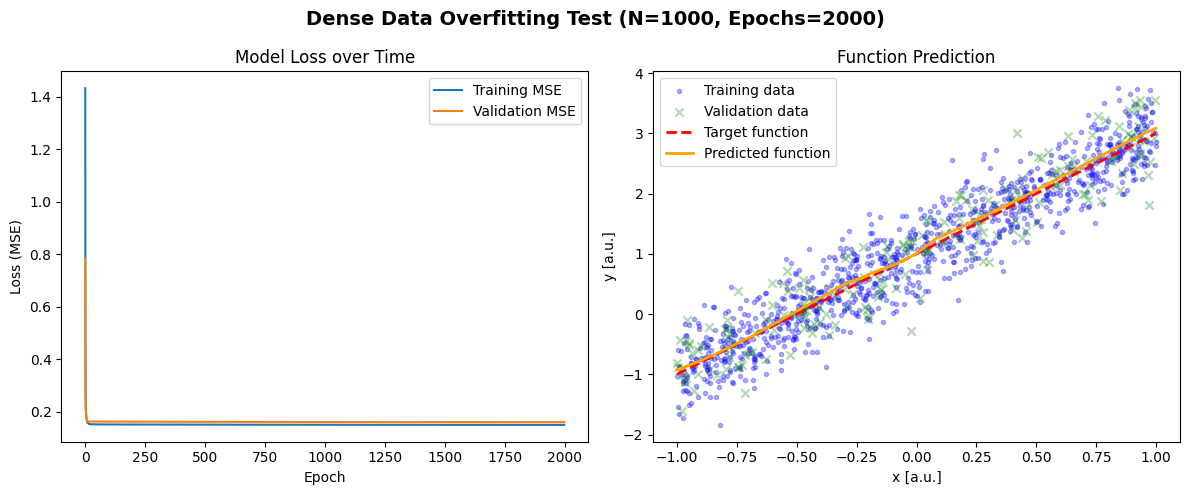

In [7]:
# Train the exact same network on 1000 points
run_complex_model_trial(n_train=1000, n_valid=200, batch_size=32, 
                        title="Dense Data Overfitting Test (N=1000, Epochs=2000)", force_retrain=False)

The previous tests explicitly demonstrate that this complex architecture is an absolute overkill for this kind of linear problem. By granting the network massive mathematical capacity, we allowed it to abandon the search for the underlying physical law and instead memorize the random variance of our specific dataset.

### Limits of Over-Parameterization and Epochs

From these experiments, we can extract critical guidelines for building models when the underlying true function is unknown:

* **More epochs can be dangerous:** In highly complex models, simply increasing the training time ($N_{\mathrm{epochs}}$) is not necessarily the best option. Without early stopping, an over-parameterized model will eventually perfectly fit the training data at the cost of generalization.
* **Data Quality over Training Time:** Improving the quality of the data (reducing the variance/noise, $\sigma$) provides a much cleaner gradient for the network to follow, leading to a faster and more stable convergence.
* **Data Quantity Smooths Complexity:** When noise is unavoidable, increasing the sheer quantity of data ($N_{\mathrm{train}}$) is the best defense against overfitting. A dense dataset forces the network to find the general trend, as it becomes mathematically impossible to weave a path through thousands of conflicting noisy points without incurring massive penalties.

Ultimately, the goal of machine learning is not to minimize the training error to zero, but to discover the simplest model that captures the true underlying mechanics of the system.

## Exercise 11.2: Fitting a Polynomial

In this exercise, we extend our neural network to fit a 3rd-order polynomial:
$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$. 

Fitting a cubic function requires more architectural care than a simple line. We must select appropriate hyperparameters:
* **Hidden Layers:** We will use two hidden layers to give the network enough capacity to bend and map the non-linear curves.
* **Activation Function:** We use `tanh` because it is naturally smooth and continuously differentiable, avoiding the jagged, piecewise straight lines produced by `relu`.
* **Loss Function:** We use Mean Absolute Error (`mae`). Unlike MSE, which squares small errors into insignificance, MAE applies a constant penalty. This prevents the optimizer from getting "lazy" and forces it to trace subtle local minima.
* **Optimizer:** We switch to `adam`, which adapts its learning rate dynamically and navigates the complex loss landscapes of polynomials much faster than standard `sgd`.

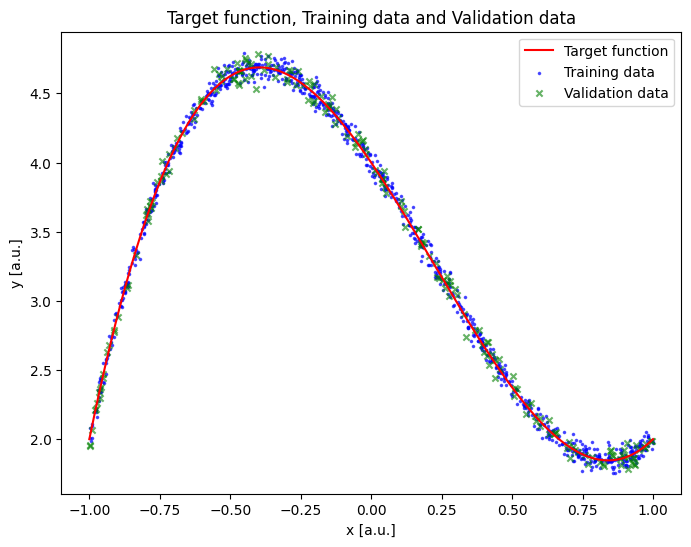

In [8]:
# First plot the function and generate the dataset
x = np.linspace(-1, 1, 1000)
y = 4 - 3*x - 2*x**2 + 3*x**3

sigma = 0.05

np.random.seed(0)
tf.random.set_seed(0)

x_train = np.random.uniform(-1, 1, 1000)
x_valid = np.random.uniform(-1, 1, 200)
y_train = np.random.normal((4 - 3*x_train - 2*x_train**2 + 3*x_train**3), sigma)
y_valid = np.random.normal((4 - 3*x_valid - 2*x_valid**2 + 3*x_valid**3), sigma)

plt.figure(figsize=(8,6))
plt.plot(x, y, c='r', label='Target function')
plt.scatter(x_train, y_train, marker='.', c='b', alpha=0.6, s=10, label='Training data')
plt.scatter(x_valid, y_valid, marker='x', c='g', alpha=0.6, s=20, label='Validation data')

plt.title("Target function, Training data and Validation data")
plt.xlabel("x [a.u.]")
plt.ylabel("y [a.u.]")
plt.legend()
plt.show()

### Model Compilation and Training
We construct the Sequential model and train it for 2000 epochs. This extended training duration ensures that the `adam` optimizer has enough time to fully minimize the Mean Absolute Error and accurately map the primary, global curves of the polynomial. However, as we will observe in the results, neural networks naturally struggle at the absolute boundaries of their training data.

In [9]:
# Hyperparameter Configuration
n_layers = 2
n_neurons = 32
activation_func = 'tanh'
n_epochs = 2000
batch_sz = 32
force_retrain = False

# Creates a name like: "model_4x64_swish_1500ep.keras"
signature = f"{n_layers}x{n_neurons}_{activation_func}_{n_epochs}ep"
base_model_name = f"poly_model_{signature}.keras"
base_history_name = f"poly_history_{signature}.pkl"

# Logic: Load or Train
if os.path.exists(base_model_name) and not force_retrain:
    print(f"Loading existing model from '{base_model_name}'...")
    
    model = load_model(base_model_name)
    
    with open(base_history_name, "rb") as file_pi:
        loaded_history_dict = pickle.load(file_pi)
        class MockHistory: pass
        history = MockHistory()
        history.history = loaded_history_dict

else:
    print(f"Building and training new model ({signature})...")
    
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(1,)))
    
    # Dynamically build the hidden layers based on the config above
    for _ in range(n_layers):
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation_func))
        
    model.add(tf.keras.layers.Dense(1))

    model.compile(optimizer='adam', loss='mae', metrics=['mse'])

    history = model.fit(
        x = x_train, y = y_train,
        batch_size = batch_sz, epochs = n_epochs,
        shuffle=True, validation_data=(x_valid, y_valid),
        verbose=0 
    )
    
    # Determine Filenames (Avoid overwriting an existing perfect model)
    if os.path.exists(base_model_name) and force_retrain:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_model_name = f"poly_model_{signature}_{timestamp}.keras"
        save_history_name = f"poly_history_{signature}_{timestamp}.pkl"
        print("Base file exists. Saving as distinct files with timestamp.")
    else:
        save_model_name = base_model_name
        save_history_name = base_history_name
        
    # Save Model and History
    model.save(save_model_name)
    with open(save_history_name, 'wb') as file_pi:
        pickle.dump(history.history, file_pi)
        
    print(f"Training complete. Files saved as '{save_model_name}'")

Loading existing model from 'poly_model_2x32_tanh_2000ep.keras'...


### Quantitative and Visual Evaluation

To rigorously evaluate the model, we calculate standard error metrics alongside the **$R^2$ Score (Coefficient of Determination)**. 

The $R^2$ score is the proportion of the variation in the dependent variable that is predictable from the independent variable(s). In other words it measures how much more significant the prediction of a certain fit function is with respect to the mean of the data. The coefficient of determination can be more intuitively informative than MAE, MSE, and RMSE in regression analysis evaluation, as the former can be expressed as a percentage, whereas the latter measures have arbitrary ranges. References are [Wikipedia](https://en.wikipedia.org/wiki/Coefficient_of_determination) and [YouTube](https://www.youtube.com/watch?v=bMccdk8EdGo).

The formula for $R^2$ is

$$R^2 = \frac{\text{variance around the mean} - \text{variance around the fit function}}{\text{variance around the mean}}$$

* An $R^2$ of **1.0** indicates a flawless, perfect prediction: there is no variation around the fit function, therefore all the variation in the data is due to the relation between the dependent and independent variable. 
* An $R^2$ of **0.0** means the model is no better than drawing a flat horizontal line through the average of all $y$ values: the variation around the fit function is exactly the same as the variation around the mean, so no information on the variation of the data can be extracted from the relation between the dependent and independent variable.

* An $R^2$ close to **0.90 or higher** is generally considered an excellent fit for noisy regression data.

Validation MAE (Average absolute error): 0.0440
Validation MSE (Mean squared error):     0.0030
R-squared Score: 0.9973


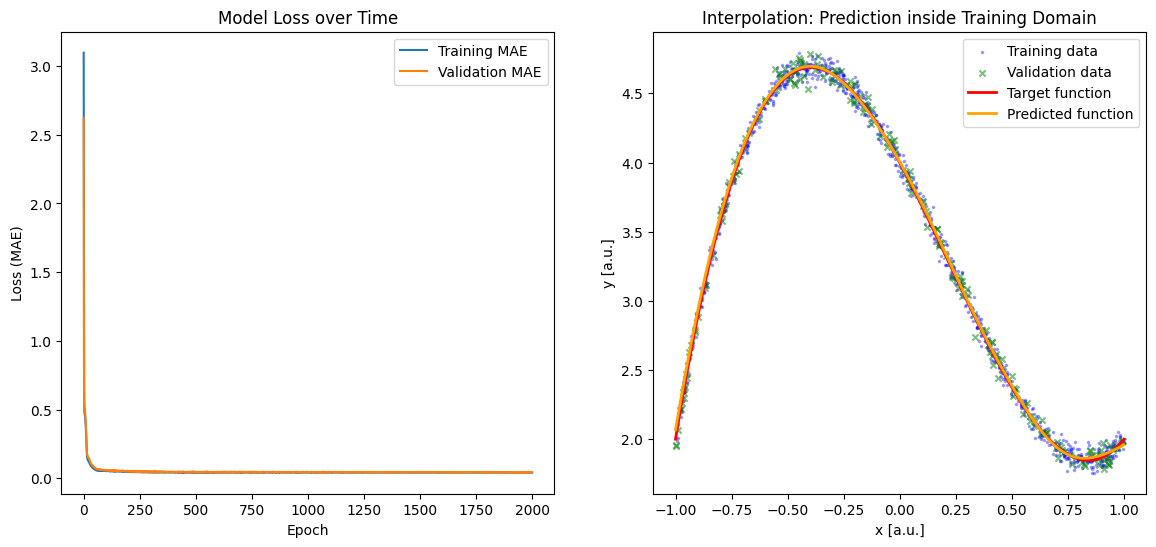

In [10]:
# Quantitative Evaluation
scores = model.evaluate(x_valid, y_valid, verbose=0)
print(f"Validation MAE (Average absolute error): {scores[0]:.4f}")
print(f"Validation MSE (Mean squared error):     {scores[1]:.4f}")

y_valid_pred = model.predict(x_valid, verbose=0)
r2 = r2_score(y_valid, y_valid_pred)
print(f"R-squared Score: {r2:.4f}")

# Visual Evaluation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Loss Plot
ax1.plot(history.history['loss'], label='Training MAE')
ax1.plot(history.history['val_loss'], label='Validation MAE')
ax1.set_title('Model Loss over Time')
ax1.set_ylabel('Loss (MAE)')
ax1.set_xlabel('Epoch')
ax1.legend()

# Prediction Plot
ax2.scatter(x_train, y_train, marker='.', c='b', alpha=0.3, s=10, label='Training data')
ax2.scatter(x_valid, y_valid, marker='x', c='g', alpha=0.5, s=20, label='Validation data')
ax2.plot(x, y, c='r', linewidth=2, label='Target function')

y_model = model.predict(x, verbose=0)
ax2.plot(x, y_model, c='orange', linewidth=2, label='Predicted function')

ax2.set_title("Interpolation: Prediction inside Training Domain")
ax2.set_xlabel("x [a.u.]")
ax2.set_ylabel("y [a.u.]")
ax2.legend()
plt.show()

### The Danger of Extrapolation

Inside the bulk of the $x \in [-1, 1]$ range, the interpolation is highly accurate, successfully mapping the main peaks and valleys. However, looking closely at the extreme boundaries ($x=-1.0$ and $x=1.0$), we observe an **edge effect**: the predicted curve begins to flatten out, diverging from the true polynomial. 

This occurs because there is no training data beyond those edges to guide the network, and the `tanh` activation function naturally plateaus at its extremes.

This edge flattening is the perfect transition to the problem of **extrapolation**. A neural network does not learn the abstract mathematical equation of $x^3$. It only learns to map specific input ranges to specific output ranges. When we input values outside the safe $[-1, 1]$ zone, the nodes quickly saturate, causing the network's prediction to completely flatline and fail to capture the aggressive vertical growth of the cubic function.

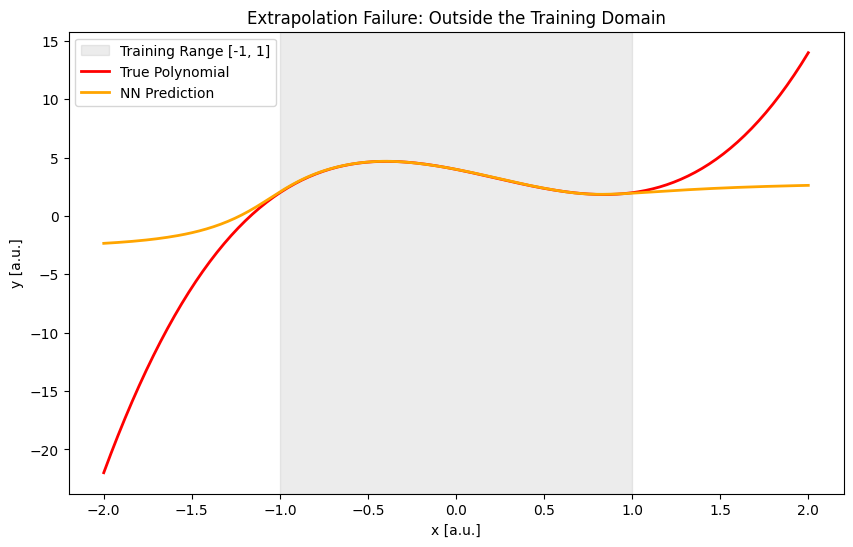

In [11]:
# Generate data outside the training range
x_extrap = np.linspace(-2, 2, 200) # Expanded to [-2, 2]
y_extrap_target = 4 - 3*x_extrap - 2*x_extrap**2 + 3*x_extrap**3
y_extrap_pred = model.predict(x_extrap, verbose=0)

plt.figure(figsize=(10,6))

# Highlight the safe training zone
plt.axvspan(-1, 1, color='gray', alpha=0.15, label='Training Range [-1, 1]')

plt.plot(x_extrap, y_extrap_target, c='r', linewidth=2, label='True Polynomial')
plt.plot(x_extrap, y_extrap_pred, c='orange', linewidth=2, label='NN Prediction')

plt.title("Extrapolation Failure: Outside the Training Domain")
plt.xlabel("x [a.u.]")
plt.ylabel("y [a.u.]")
plt.legend()
plt.show()

## Exercise 11.3: Fitting a 2D Surface

In this final exercise, we extend our network to accept two inputs and predict a single output, modeling the trigonometric 2D function:
$$f(x,y) = \sin(x^2+y^2)$$ 
for $x \in [-1.5, 1.5]$ and $y \in [-1.5, 1.5]$.

### Modeling the 3D Geometry

Because this function resembles a wavy bowl, it contains complex, non-linear curvature in multiple directions. We adapt our network by:
1. **Input Shape:** Changing the input to `(2,)` to accept the `[x, y]` coordinate pairs.
2. **Architecture:** Using four hidden layers of 64 `swish` neurons. The `swish` activation function provides the smoothness needed to accurately map the 3D ripples without suffering from the "vanishing gradient" (flat-plane) problem that plagues deep `tanh` networks.

The `swish` activation function is defined as
$$f(x) = x * \text{sigmoid}(x) = \frac{x}{1+e^{-x}}$$

#### Implementing Early Stopping

After analyzing the initial training runs, I decided to adopt an Early Stopping mechanism for this problem. When observing the validation loss over 1500 epochs, a distinct pattern emerged: the loss would dip to a minimum and then steadily rise, a classic indicator that the network was transitioning from learning the function to overfitting the noise.

Early Stopping allows us to automatically monitor the validation loss and halt the training process as soon as it begins to degrade. To implement this robustly, I configured two key parameters:

- **Patience (`patience=50`):** This ensures that the training does not stop prematurely due to minor, temporary statistical fluctuations in the loss curve. The network must see no improvement for 50 consecutive epochs before it decides to quit.

- **Restoring Optimal Parameters (`restore_best_weights=True`)**: This is a critical setting. Because the training halts 50 epochs after the optimal minimum was reached, the weights at the final epoch are already slightly overfitted. This parameter guarantees that the network discards those final 50 epochs and reverts its weights and biases back to the exact point where the validation loss was at its absolute lowest.

As a secondary benefit, implementing this strategy drastically reduces the overall computation time, as the network stops training the moment further epochs become detrimental.

In [17]:
# Generate Meshgrid for Mathematical Plotting
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X**2 + Y**2)

# Generate Random Pairs for Neural Network Training
n_train = 5000
n_valid = 500
sigma = 0.05 

np.random.seed(0)
tf.random.set_seed(0)

x_train = np.random.uniform(-1.5, 1.5, n_train)
y_train = np.random.uniform(-1.5, 1.5, n_train)
x_valid = np.random.uniform(-1.5, 1.5, n_valid)
y_valid = np.random.uniform(-1.5, 1.5, n_valid)

# Calculate target Z and inject noise
z_train = np.sin(x_train**2 + y_train**2) + np.random.normal(0, sigma, n_train)
z_valid = np.sin(x_valid**2 + y_valid**2) + np.random.normal(0, sigma, n_valid)

# Stack x and y into a single (N, 2) array for Keras
inputs_train = np.column_stack((x_train, y_train))
inputs_valid = np.column_stack((x_valid, y_valid))

print("Training input shape:", inputs_train.shape)

Training input shape: (5000, 2)


In [18]:
# Hyperparameter Configuration
n_layers = 4
n_neurons = 64
activation_func = 'swish'
n_epochs = 1500
batch_sz = 32
dropout_rate = 0.0

force_retrain = False

# Creates a name like: "model_4x64_swish_1500ep.keras"
signature = f"{n_layers}x{n_neurons}_{activation_func}_drop{dropout_rate}_{n_epochs}ep"
base_model_name = f"2Dsine_model_{signature}.keras"
base_history_name = f"2Dsine_history_{signature}.pkl"

# Logic: Load or Train
if os.path.exists(base_model_name) and not force_retrain:
    print(f"Loading existing model from '{base_model_name}'...")
    
    model = load_model(base_model_name)
    
    with open(base_history_name, "rb") as file_pi:
        loaded_history_dict = pickle.load(file_pi)
        class MockHistory: pass
        history = MockHistory()
        history.history = loaded_history_dict

else:
    print(f"Building and training new model ({signature})...")

    callback = EarlyStopping( monitor="val_loss",
                              patience=50,
                              verbose=0,
                              restore_best_weights=True,
                              start_from_epoch=0,
                            )
    
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    
    # Dynamically build the hidden layers based on the config above
    for _ in range(n_layers):
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation_func))
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))
        
    model.add(tf.keras.layers.Dense(1))

    model.compile(optimizer='adam', loss='mae', metrics=['mse'])

    history = model.fit(
        x = inputs_train, y = z_train,
        batch_size = batch_sz, callbacks = [callback], epochs = n_epochs,
        shuffle=True, validation_data=(inputs_valid, z_valid),
        verbose=0 
    )
    
    # Determine Filenames (Avoid overwriting an existing perfect model)
    if os.path.exists(base_model_name) and force_retrain:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_model_name = f"2Dsine_model_{signature}_{timestamp}.keras"
        save_history_name = f"2Dsine_history_{signature}_{timestamp}.pkl"
        print("Base file exists. Saving as distinct files with timestamp.")
    else:
        save_model_name = base_model_name
        save_history_name = base_history_name
        
    # Save Model and History
    model.save(save_model_name)
    with open(save_history_name, 'wb') as file_pi:
        pickle.dump(history.history, file_pi)
        
    print(f"Training complete. Files saved as '{save_model_name}'")

Loading existing model from '2Dsine_model_4x64_swish_drop0.0_1500ep.keras'...


### Visualizing the Prediction and Metrics

To evaluate the model's performance visually, we pass the flattened mathematical meshgrid through the network and reshape the predictions back into a 2D grid. We then plot the model's training loss alongside a static 3D projection of the prediction wireframe overlapping the true mathematical surface.

In [19]:
# Quantitative Metrics
scores = model.evaluate(inputs_valid, z_valid, verbose=0)
val_mae = scores[0]
val_mse = scores[1]

# Generate predictions and calculate R-squared
z_valid_pred = model.predict(inputs_valid, verbose=0)
r2 = r2_score(z_valid, z_valid_pred)

print(f"Validation MAE (Average absolute error): {val_mae:.4f}")
print(f"Validation MSE (Mean squared error):     {val_mse:.4f}")
print(f"R-squared Score: {r2:.4f}")


# Generate 3D Surface Data
grid_points = np.column_stack((X.flatten(), Y.flatten()))
z_pred_flat = model.predict(grid_points, verbose=0)
Z_pred = z_pred_flat.reshape(X.shape)

Validation MAE (Average absolute error): 0.0402
Validation MSE (Mean squared error):     0.0027
R-squared Score: 0.9816


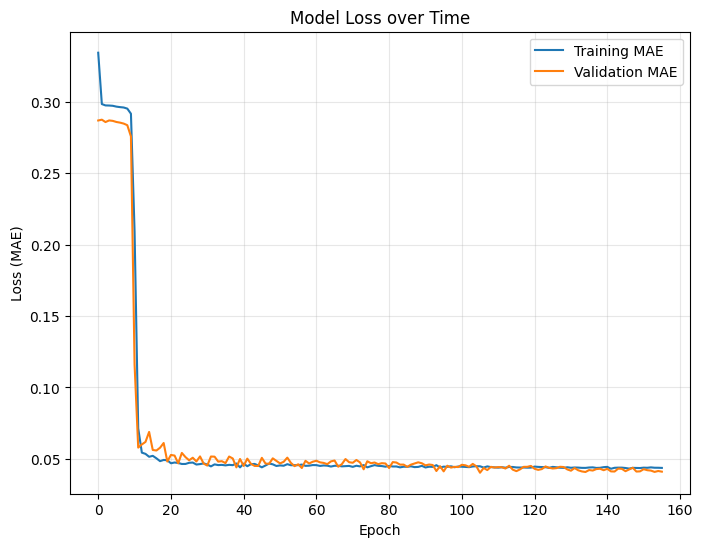

In [20]:
# Model loss over time
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training MAE')
plt.plot(history.history['val_loss'], label='Validation MAE')
plt.title('Model Loss over Time')
plt.ylabel('Loss (MAE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

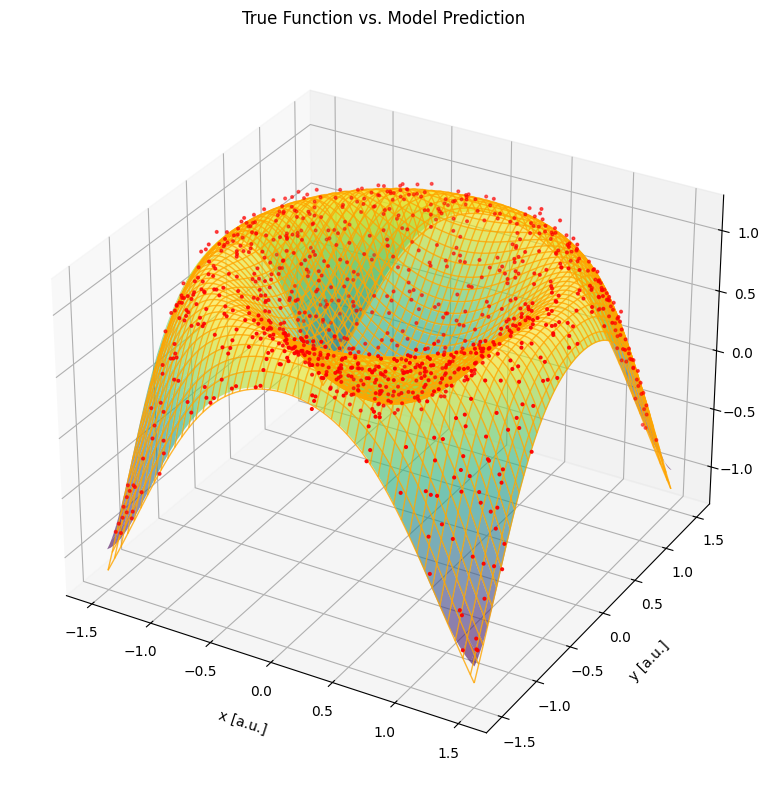

In [21]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# True surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)

# Model's prediction
ax.plot_wireframe(X, Y, Z_pred, color='orange', alpha=0.8, linewidth=1.0)

# Subset of the noisy training data
ax.scatter(x_train[:1000], y_train[:1000], z_train[:1000], 
            c='red', marker='.', s=15, label='Training Data')

ax.set_title("True Function vs. Model Prediction")
ax.set_xlabel("x [a.u.]", labelpad=10)
ax.set_ylabel("y [a.u.]", labelpad=10)
ax.set_zlabel("z [a.u.]", labelpad=10)

plt.tight_layout() 
plt.show()

The model shows excellent convergence in the center of the training interval, successfully learning the central "bowl" structure. However, as expected, its performance degrades at the boundaries. This edge effect occurs because the function's curvature becomes more complex further from the origin, and the network lacks data outside the training domain to adequately constrain its predictions in those regions.